In [123]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [10]:
results= pd.read_csv('game_stats.csv')
results.head()

,Date,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,...,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO,Own goals,Own goal Time
0,14-06-2018,Russia,Saudi Arabia,5,40,13,7,3,3,6,...,0,0,0,Yes,12.0,Group Stage,No,0,NaN,NaN
1,14-06-2018,Saudi Arabia,Russia,0,60,6,0,3,3,2,...,0,0,0,No,NaN,Group Stage,No,0,NaN,NaN
2,15-06-2018,Egypt,Uruguay,0,43,8,3,3,2,0,...,2,0,0,No,NaN,Group Stage,No,0,NaN,NaN
3,15-06-2018,Uruguay,Egypt,1,57,14,4,6,4,5,...,0,0,0,Yes,89.0,Group Stage,No,0,NaN,NaN
4,15-06-2018,Morocco,Iran,0,64,13,3,6,4,5,...,1,0,0,No,NaN,Group Stage,No,0,1.0,90.0


In [15]:
#Number of Rows & Columns
num_records = results.shape[0]
num_features = results.shape[1]

print(f"Rows count: {num_records}")
print(f"Columns count: {num_features}")

Rows count: 128
Columns count: 27


In [17]:
#Data types
print("Data types of each feature: ")
print(results.dtypes)

Data types of each feature: 
Date                       object
Team                       object
Opponent                   object
Goal Scored                 int64
Ball Possession %           int64
Attempts                    int64
On-Target                   int64
Off-Target                  int64
Blocked                     int64
Corners                     int64
Offsides                    int64
Free Kicks                  int64
Saves                       int64
Pass Accuracy %             int64
Passes                      int64
Distance Covered (Kms)      int64
Fouls Committed             int64
Yellow Card                 int64
Yellow & Red                int64
Red                         int64
Man of the Match           object
1st Goal                  float64
Round                      object
PSO                        object
Goals in PSO                int64
Own goals                 float64
Own goal Time             float64
dtype: object


In [19]:
SecondHalf_prob = round(((results['1st Goal']>45).sum())/len(results),2)
FirstHalf_prob = round(((results['1st Goal']<45).sum())/len(results),2)
null_prob = (results['1st Goal'].isnull().sum())/len(results)

print(f"Probability that the first goal was scored in first Half: {FirstHalf_prob}")
print(f"Probability that the first goal was scored in Second Half: {SecondHalf_prob}")

Probability that the first goal was scored in first Half: 0.41
Probability that the first goal was scored in Second Half: 0.31


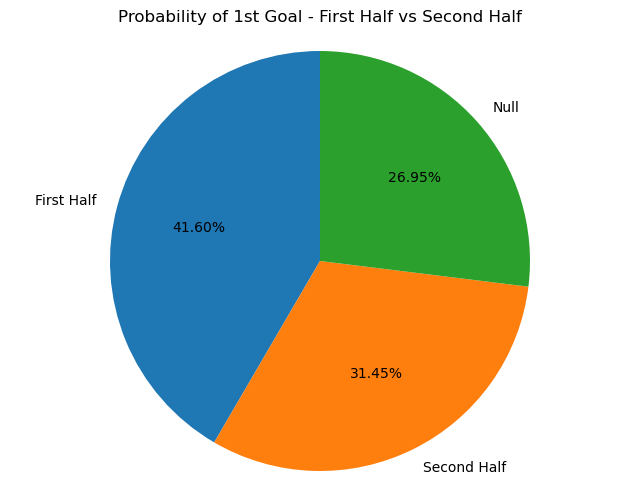

In [21]:
labels = ['First Half', 'Second Half', 'Null']
sizes = [FirstHalf_prob, SecondHalf_prob, null_prob]
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90)
plt.title('Probability of 1st Goal - First Half vs Second Half')
plt.axis('equal')
plt.show()

In [65]:
print("Null values could mean that the game ended in a draw with no goals, i came to this conclusion after comparing null vslues in the 1sr Goal feature and the other features")

Null values could mean that the game ended in a draw with no goals, i came to this conclusion after comparing null vslues in the 1sr Goal feature and the other features


In [23]:
#Handling Missing Values
print(round(results.isnull().sum()/len(results)*100,2))

Date                       0.00
Team                       0.00
Opponent                   0.00
Goal Scored                0.00
Ball Possession %          0.00
Attempts                   0.00
On-Target                  0.00
Off-Target                 0.00
Blocked                    0.00
Corners                    0.00
Offsides                   0.00
Free Kicks                 0.00
Saves                      0.00
Pass Accuracy %            0.00
Passes                     0.00
Distance Covered (Kms)     0.00
Fouls Committed            0.00
Yellow Card                0.00
Yellow & Red               0.00
Red                        0.00
Man of the Match           0.00
1st Goal                  26.56
Round                      0.00
PSO                        0.00
Goals in PSO               0.00
Own goals                 90.62
Own goal Time             90.62
dtype: float64


In [93]:
print("Own goals and Own goal time's data is 90% null, therefore we can drop this feature because if we try to replace the null value with the median or the mean, we will be basically constructing our ")

Own goals and Own goal time's data is 90% null, therefore we can drop this feature because if we try to replace the null value with the median or the mean, we will be basically constructing our 


In [37]:
results = results.drop(columns=['Own goals', 'Own goal Time'])
results.head()

,Date,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,...,Distance Covered (Kms),Fouls Committed,Yellow Card,Yellow & Red,Red,Man of the Match,1st Goal,Round,PSO,Goals in PSO
0,14-06-2018,Russia,Saudi Arabia,5,40,13,7,3,3,6,...,118,22,0,0,0,Yes,12.00,Group Stage,No,0
1,14-06-2018,Saudi Arabia,Russia,0,60,6,0,3,3,2,...,105,10,0,0,0,No,39.46,Group Stage,No,0
2,15-06-2018,Egypt,Uruguay,0,43,8,3,3,2,0,...,112,12,2,0,0,No,39.46,Group Stage,No,0
3,15-06-2018,Uruguay,Egypt,1,57,14,4,6,4,5,...,111,6,0,0,0,Yes,89.00,Group Stage,No,0
4,15-06-2018,Morocco,Iran,0,64,13,3,6,4,5,...,101,22,1,0,0,No,39.46,Group Stage,No,0


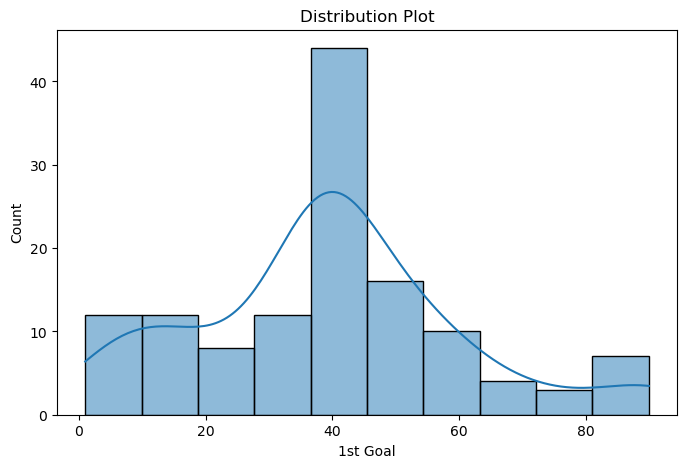

Skewnes Score: 0.4


In [39]:
#Histogram to check the distribution or skewness of the dataset
plt.figure(figsize=(8, 5))
sns.histplot(results['1st Goal'], kde=True)
plt.title('Distribution Plot')
plt.show()

skew_score = results['1st Goal'].skew()
print(f"Skewnes Score: {round(skew_score,2)}")

In [61]:
print('From the histogram we can see that the data is not skewed, as the values are concentrated at the center and from the skewness score value is between -0.5 and 0.5 which tells us the data is not skewed. Since the data is normaly distributed we can replace the null values in this column with the mean')

mean = round(results['1st Goal'].mean(),2)
results['1st Goal'] = results['1st Goal'].fillna(mean)
print(results.head())

From the histogram we can see that the data is not skewed, as the values are concentrated at the center and from the skewness score value is between -0.5 and 0.5 which tells us the data is not skewed. Since the data is normaly distributed we can replace the null values in this column with the mean
           Team      Opponent  Goal Scored  Ball Possession %  Attempts  \
0        Russia  Saudi Arabia            5                 40        13   
1  Saudi Arabia        Russia            0                 60         6   
2         Egypt       Uruguay            0                 43         8   
3       Uruguay         Egypt            1                 57        14   
4       Morocco          Iran            0                 64        13   

   On-Target  Off-Target  Blocked  Corners  Offsides  ...  \
0          7           3        3        6         3  ...   
1          0           3        3        2         1  ...   
2          3           3        2        0         1  ...   
3     

In [73]:
results = results.drop(columns=['Date'])
results.head()


,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,...,Fouls Committed,Yellow Card,Yellow & Red,Red,1st Goal,Round,PSO,Goals in PSO,Man of the Match_No,Man of the Match_Yes
0,Russia,Saudi Arabia,5,40,13,7,3,3,6,3,...,22,0,0,0,12.00,Group Stage,No,0,False,True
1,Saudi Arabia,Russia,0,60,6,0,3,3,2,1,...,10,0,0,0,39.46,Group Stage,No,0,True,False
2,Egypt,Uruguay,0,43,8,3,3,2,0,1,...,12,2,0,0,39.46,Group Stage,No,0,True,False
3,Uruguay,Egypt,1,57,14,4,6,4,5,1,...,6,0,0,0,89.00,Group Stage,No,0,False,True
4,Morocco,Iran,0,64,13,3,6,4,5,0,...,22,1,0,0,39.46,Group Stage,No,0,True,False


In [85]:
results['Man of the Match'] = results['Man of the Match'].map({'Yes': 1, 'No': 0})
results.head()

,Team,Opponent,Goal Scored,Ball Possession %,Attempts,On-Target,Off-Target,Blocked,Corners,Offsides,...,Distance Covered (Kms),Fouls Committed,Yellow Card,Yellow & Red,Red,1st Goal,Round,PSO,Goals in PSO,Man of the Match
0,Russia,Saudi Arabia,5,40,13,7,3,3,6,3,...,118,22,0,0,0,12.00,Group Stage,No,0,1
1,Saudi Arabia,Russia,0,60,6,0,3,3,2,1,...,105,10,0,0,0,39.46,Group Stage,No,0,0
2,Egypt,Uruguay,0,43,8,3,3,2,0,1,...,112,12,2,0,0,39.46,Group Stage,No,0,0
3,Uruguay,Egypt,1,57,14,4,6,4,5,1,...,111,6,0,0,0,89.00,Group Stage,No,0,1
4,Morocco,Iran,0,64,13,3,6,4,5,0,...,101,22,1,0,0,39.46,Group Stage,No,0,0


In [103]:
text_columns = []
for col in results.columns: 
    if results[col].dtype == 'object':
        text_columns.append(col)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore' ).set_output(transform='pandas')
one_encoding  = []

for col in text_columns:
    unique_count = results[col].nunique()
    if unique_count < 10:
        results[col] = results[col].astype('category').cat.codes
    else:
        one_encoding.append(col)
if len(one_encoding):
    encoded_df = ohe.fit_transform(results[one_encoding])
    results = results.drop(columns=one_encoding)
    results = pd.concat([results, encoded_df], axis=1)

print(results.head())

   Goal Scored  Ball Possession %  Attempts  On-Target  Off-Target  Blocked  \
0            5                 40        13          7           3        3   
1            0                 60         6          0           3        3   
2            0                 43         8          3           3        2   
3            1                 57        14          4           6        4   
4            0                 64        13          3           6        4   

   Corners  Offsides  Free Kicks  Saves  ...  Opponent_Portugal  \
0        6         3          11      0  ...                0.0   
1        2         1          25      2  ...                0.0   
2        0         1           7      3  ...                0.0   
3        5         1          13      3  ...                0.0   
4        5         0          14      2  ...                0.0   

   Opponent_Russia  Opponent_Saudi Arabia  Opponent_Senegal  Opponent_Serbia  \
0              0.0                    1.0 

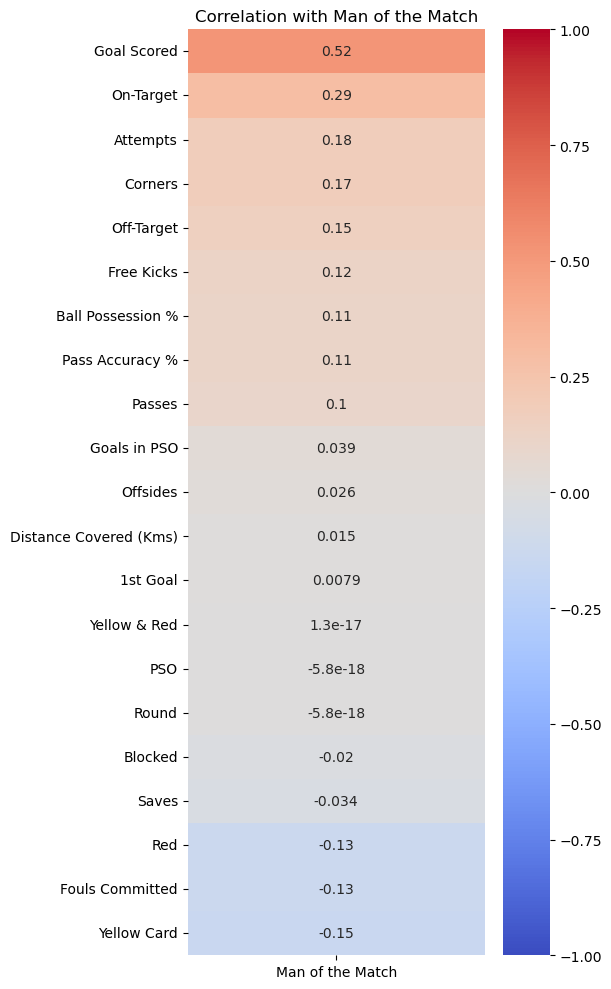

In [113]:
#Correlation between man of the match and other features
cols_to_keep = [col for col in results.columns if col not in encoded_df]
numeric_df = results[cols_to_keep]
corr = numeric_df.corr()

corr_vector = corr[['Man of the Match']].sort_values(by='Man of the Match', ascending=False)
corr_vector = corr_vector.drop('Man of the Match')

plt.figure(figsize=(6, 10)) # Tall figure to fit the vector nicely
plt.title("Correlation with Man of the Match")

# Plot using Seaborn
sns.heatmap(corr_vector, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.tight_layout()
plt.show()

In [121]:
print('Correlation Analysis')
print('Goal scored is highly correlated to the man of the match award, this means that the team that scores most goals have the highest chance to produce the player that will win the man of the match award. On target shots are also highly correlated to the man of the match award, meaning that even though there are not goals in that match the man of the match can come from a team with more shots on target.')

Correlation Analysis
Goal scored is highly correlated to the man of the match award, this means that the team that scores most goals have the highest chance to produce the player that will win the man of the match award. On target shots are also highly correlated to the man of the match award, meaning that even though there are not goals in that match the man of the match can come from a team with more shots on target.


In [135]:
#80/20 split
X = results.drop(columns=['Man of the Match'])
Y = results['Man of the Match']

X_train, X_test,Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("--- Dataset Dimensions ---")
print(f"X_train shape: {X_train.shape} (80% of features)")
print(f"y_train shape: {Y_train.shape}  (80% of target)")
print(f"X_test shape:  {X_test.shape}  (20% of features)")
print(f"y_test shape:  {Y_test.shape}   (20% of target)")

--- Dataset Dimensions ---
X_train shape: (102, 85) (80% of features)
y_train shape: (102,)  (80% of target)
X_test shape:  (26, 85)  (20% of features)
y_test shape:  (26,)   (20% of target)


In [141]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, learning_curve

models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# 2 & 3. Perform 10-fold cross-validation and report accuracy/F1
print("--- 10-Fold Cross-Validation Results (Training Set) ---")
for name, model in models.items():
    scores = cross_validate(model, X_train, Y_train, cv=10, scoring=['accuracy', 'f1'])
    
    # Calculate the mean of the 10 folds
    mean_acc = scores['test_accuracy'].mean()
    mean_f1 = scores['test_f1'].mean()
    
    print(f"{name}:")
    print(f"  CV Accuracy: {mean_acc:.4f}")
    print(f"  CV F1 Score: {mean_f1:.4f}\n")

--- 10-Fold Cross-Validation Results (Training Set) ---
Naive Bayes:
  CV Accuracy: 0.5582
  CV F1 Score: 0.5911

Decision Tree:
  CV Accuracy: 0.7645
  CV F1 Score: 0.7595



C:\Users\narer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\narer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression:
  CV Accuracy: 0.6645
  CV F1 Score: 0.6288



C:\Users\narer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


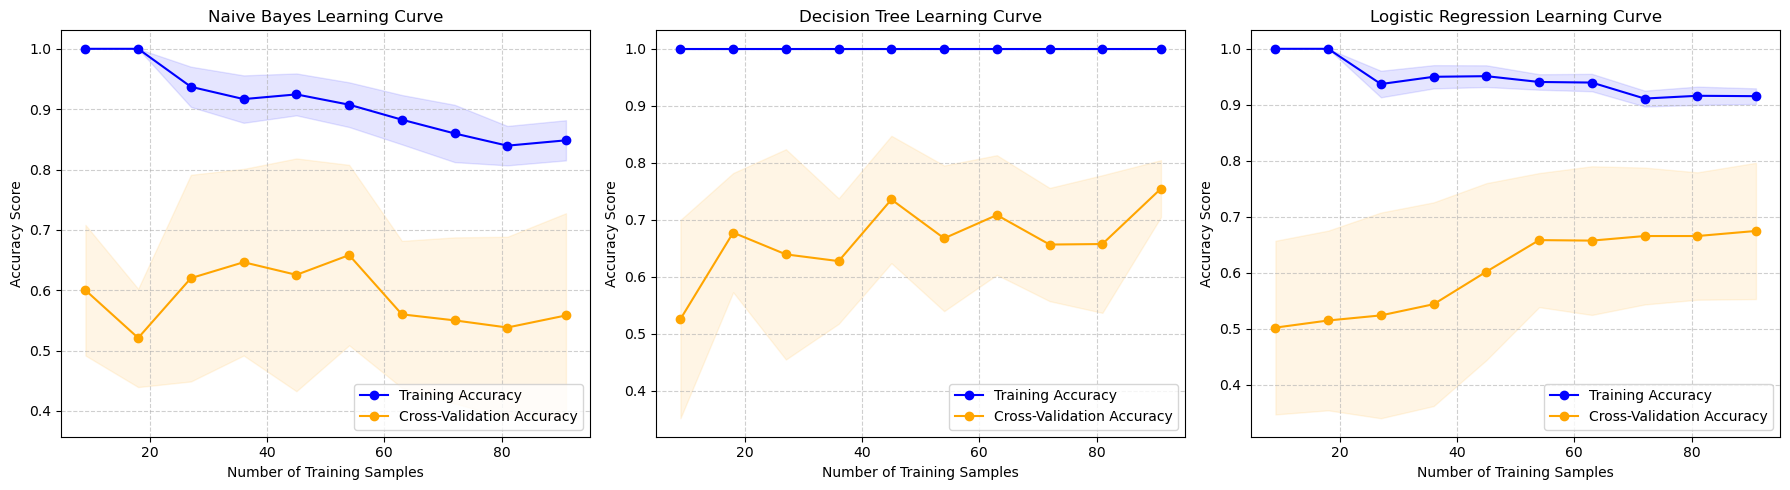

In [144]:
# 4. Draw a learning curve for each classifier
plt.figure(figsize=(18, 5)) # Wide figure to fit 3 charts side-by-side

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    
    # Calculate learning curve data across 10 chunks of the training data
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, Y_train, cv=10, scoring='accuracy', 
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
    )
    
    # Calculate means and standard deviations for the shading
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Plot the actual lines
    plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue', marker='o')
    plt.plot(train_sizes, test_mean, label='Cross-Validation Accuracy', color='orange', marker='o')
    
    # Draw the bands (standard deviation) to show variance
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.1)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='orange', alpha=0.1)
    
    # Formatting the charts
    plt.title(f"{name} Learning Curve")
    plt.xlabel("Number of Training Samples")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

--- Decision Tree Test Results ---
Test Accuracy Score: 0.7308

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.64      0.82      0.72        11
           1       0.83      0.67      0.74        15

    accuracy                           0.73        26
   macro avg       0.74      0.74      0.73        26
weighted avg       0.75      0.73      0.73        26



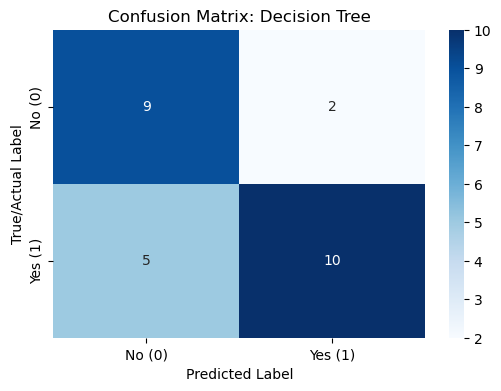

In [148]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Test using the model with the highest F1 score
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, Y_train)

y_pred = dt_model.predict(X_test)

# Calculate the required metrics
test_acc = accuracy_score(Y_test, y_pred)
conf_matrix = confusion_matrix(Y_test, y_pred)
class_report = classification_report(Y_test, y_pred)

# 5. Print the text results
print("--- Decision Tree Test Results ---")
print(f"Test Accuracy Score: {test_acc:.4f}\n")
print("--- Classification Report ---")
print(class_report)

# 6. Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No (0)', 'Yes (1)'], 
            yticklabels=['No (0)', 'Yes (1)'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True/Actual Label')
plt.show()

In [152]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')

# 2. Train and predict
dummy.fit(X_train, Y_train)
dummy_pred = dummy.predict(X_test)

# 3. Calculate the baseline metrics
# Note: zero_division=0 prevents Pandas from throwing a warning when the F1 score hits 0
dummy_acc = accuracy_score(Y_test, dummy_pred)
dummy_report = classification_report(Y_test, dummy_pred, zero_division=0)

print("--- Dummy Classifier Baseline ---")
print(f"Test Accuracy Score: {dummy_acc:.4f}\n")
print(dummy_report)

--- Dummy Classifier Baseline ---
Test Accuracy Score: 0.4231

              precision    recall  f1-score   support

           0       0.42      1.00      0.59        11
           1       0.00      0.00      0.00        15

    accuracy                           0.42        26
   macro avg       0.21      0.50      0.30        26
weighted avg       0.18      0.42      0.25        26

